<a href="https://colab.research.google.com/github/jv48391592-eng/PIPELINE-RAG-COM-FINE-TUNING-LORA-E-DISPONIBILIZA-O-VIA-API-RESTFUL/blob/main/notebook/rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CÉLULA 1 — INSTALAÇÃO

!pip install -q \
transformers \
accelerate \
bitsandbytes \
datasets \
sentencepiece \
peft \
trl \
pdfplumber \
sacrebleu \
rouge-score \
fastapi \
uvicorn \
pyngrok \
matplotlib \
pandas \
scikit-learn

In [ ]:
#CÉLULA 2 — GERAÇÃO DO DATASET (ETAPA 1)

import json
from transformers import pipeline

INPUT_TXT = "20260050979.txt"

OUTPUT_DATASET_BRUTO = "dataset_gerado_bruto.jsonl"

CHUNK_SIZES = [500, 900]

OVERLAP = 120

GENERATOR_MODEL = "Qwen/Qwen2-1.5B-Instruct"

PROMPT_TEMPLATE = """
Você é um gerador de datasets para fine-tuning de modelos de linguagem.

Baseado APENAS no texto abaixo, gere UM único par pergunta/resposta.

REGRAS:
- Não invente informações
- A pergunta deve ser clara e objetiva
- A resposta deve ser fiel ao texto
- Não use conhecimento externo
- Evite perguntas genéricas
- A resposta deve possuir entre 30 e 120 palavras

Texto:
{chunk}

Formato obrigatório:

Instruction: [pergunta]
Output: [resposta]
"""

def carregar_texto(caminho):

    with open(caminho, "r", encoding="utf-8") as f:
        return f.read()

def criar_chunks(texto, tamanho, overlap):

    chunks = []

    start = 0

    while start < len(texto):

        end = start + tamanho

        chunk = texto[start:end]

        chunks.append(chunk)

        start = end - overlap

        if start >= len(texto):
            break

    return chunks

def gerar_par(chunk, generator):

    prompt = PROMPT_TEMPLATE.format(chunk=chunk)

    try:

        output = generator(
            prompt,
            max_new_tokens=180,
            do_sample=False
        )[0]["generated_text"]

        if "Instruction:" in output and "Output:" in output:

            inst = output.split("Instruction:")[1].split("Output:")[0].strip()

            out = output.split("Output:")[1].strip()

            return {
                "Instruction": inst,
                "Output": out
            }

    except Exception as e:
        print("Erro:", e)

    return None

texto = carregar_texto(INPUT_TXT)

print(f"Texto carregado: {len(texto)} caracteres")

todos_pares = []

generator = pipeline(
    "text-generation",
    model=GENERATOR_MODEL,
    device_map="auto"
)

for tamanho in CHUNK_SIZES:

    print(f"\n=== Chunk Size: {tamanho} ===")

    chunks = criar_chunks(
        texto,
        tamanho,
        OVERLAP
    )

    print(f"Chunks gerados: {len(chunks)}")

    pares_gerados = 0

    for chunk in chunks[:150]:

        par = gerar_par(chunk, generator)

        if par:

            todos_pares.append(par)

            pares_gerados += 1

    print(f"Pares válidos: {pares_gerados}")

with open(OUTPUT_DATASET_BRUTO, "w", encoding="utf-8") as f:

    for item in todos_pares:

        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"\nDataset bruto salvo em: {OUTPUT_DATASET_BRUTO}")

print(f"Total de pares: {len(todos_pares)}")

Texto carregado: 513176 caracteres


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Chunk Size: 500 ===
Chunks gerados: 1351


[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Pares válidos: 150

=== Chunk Size: 900 ===
Chunks gerados: 658


[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Pares válidos: 150

Dataset bruto salvo em: dataset_gerado_bruto.jsonl
Total de pares: 300


In [ ]:
 #CÉLULA 3 — CURADORIA AUTOMÁTICA

import json

INPUT_FILE = "dataset_gerado_bruto.jsonl"

OUTPUT_FILE = "dataset_limpo.jsonl"

dados_limpos = []

removidos = 0

with open(INPUT_FILE, "r", encoding="utf-8") as f:

    for linha in f:

        item = json.loads(linha)

        inst = item.get("Instruction", "").strip()

        out = item.get("Output", "").strip()

        if len(inst) < 10:
            removidos += 1
            continue

        if len(out) < 30:
            removidos += 1
            continue

        if "não sei" in out.lower():
            removidos += 1
            continue

        if "não encontrado" in out.lower():
            removidos += 1
            continue

        dados_limpos.append({
            "Instruction": inst,
            "Output": out
        })

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:

    for item in dados_limpos:

        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Total válidos: {len(dados_limpos)}")

print(f"Removidos: {removidos}")

print(
    f"Percentual removido: "
    f"{(removidos/(len(dados_limpos)+removidos))*100:.2f}%"
)

Total válidos: 300
Removidos: 0
Percentual removido: 0.00%


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/295 [00:00<?, ? examples/s]


Treinando gpt-neo-125M


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Map:   0%|          | 0/295 [00:00<?, ? examples/s]

trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334


Step,Training Loss
20,3.316132
40,3.147744
60,3.034318
80,2.872069
100,2.730292
120,2.674811
140,2.646221
160,2.625691
180,2.560042
200,2.528290


Modelo salvo em: lora_gptneo


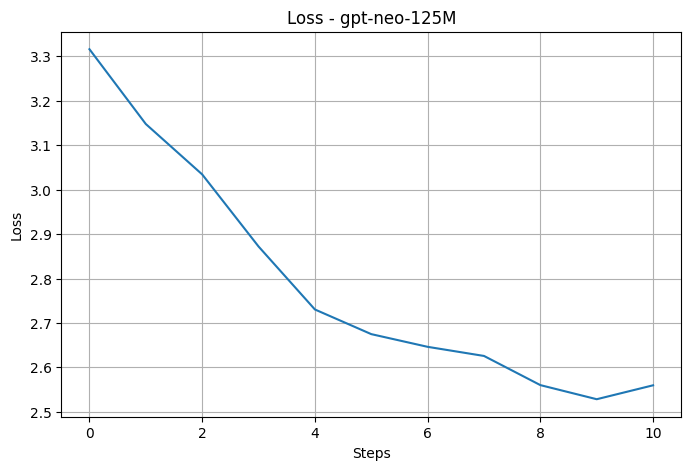


Treinando opt-125M


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Map:   0%|          | 0/295 [00:00<?, ? examples/s]

trainable params: 1,179,648 || all params: 126,418,944 || trainable%: 0.9331


model.safetensors:   0%|          | 0.00/251M [00:00<?, ?B/s]

Step,Training Loss
20,3.500631
40,3.259114
60,3.181257
80,3.077408
100,2.960553
120,2.901601
140,2.862682
160,2.879121
180,2.790961
200,2.791049


Modelo salvo em: lora_opt125


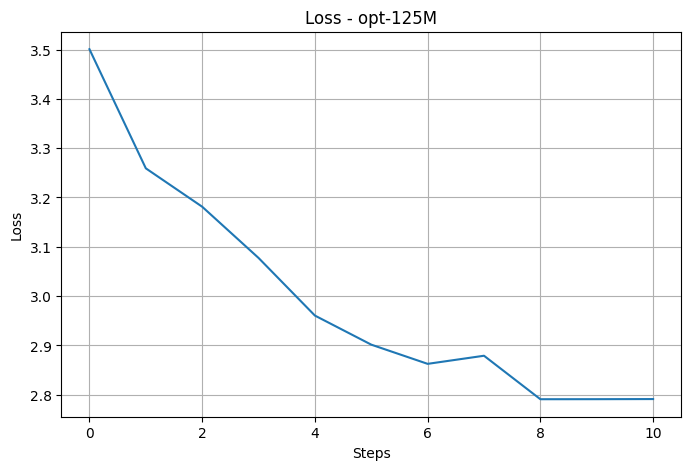


Treinando t5-small


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/295 [00:00<?, ? examples/s]

trainable params: 1,179,648 || all params: 61,686,272 || trainable%: 1.9123


Step,Training Loss
20,6.799871
40,4.571273
60,4.557102
80,4.394754
100,4.330923
120,4.335030
140,4.287363
160,4.333834
180,4.206461
200,4.211346


Modelo salvo em: lora_t5


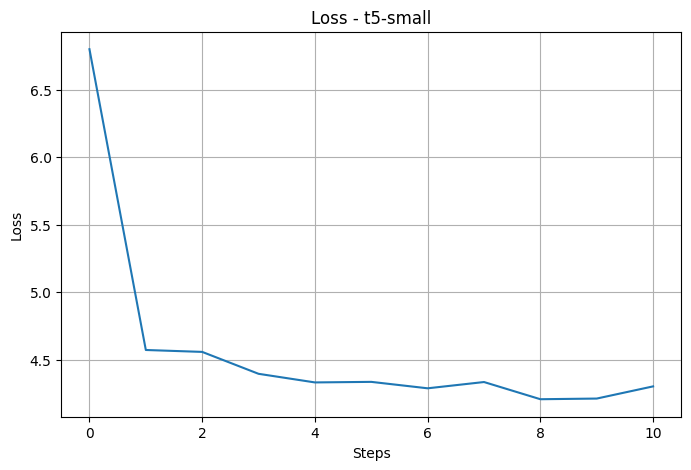


Treinando bart-base


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Map:   0%|          | 0/295 [00:00<?, ? examples/s]

trainable params: 1,769,472 || all params: 141,189,888 || trainable%: 1.2533


Step,Training Loss
20,5.201398
40,4.510768
60,4.505285
80,4.406333
100,4.323235
120,4.372724
140,4.288520
160,4.326431
180,4.247556
200,4.270631


Modelo salvo em: lora_bart


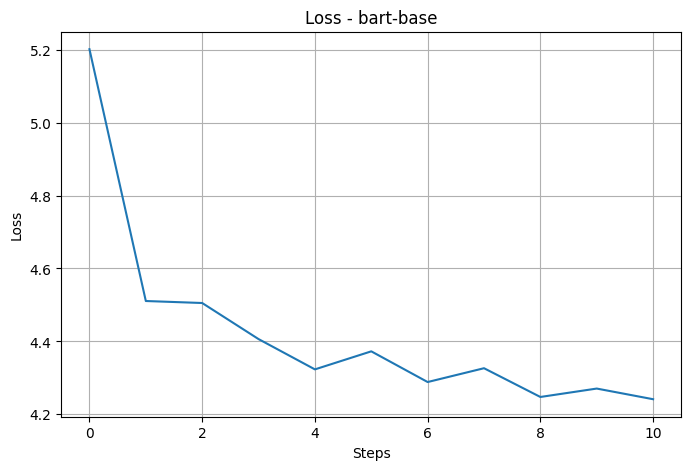

In [ ]:
#CÉLULA 4 — TREINAMENTO LoRA COMPLETO

!pip install "torchao>=0.16.0"

from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments
)

from peft import (
    LoraConfig,
    get_peft_model
)

from datasets import load_dataset

import matplotlib.pyplot as plt

dataset = load_dataset(
    "json",
    data_files="dataset_limpo.jsonl"
)["train"]

def normalize_columns(example):

    example["instruction"] = (
        example.get("instruction")
        or example.get("Instruction")
        or ""
    )

    example["output"] = (
        example.get("output")
        or example.get("Output")
        or ""
    )

    return example

dataset = dataset.map(normalize_columns)

def tokenize_causal(example, tokenizer, max_length=256):

    text = (
        f"Instruction: {example['instruction']}\n\n"
        f"Output: {example['output']}"
    )

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

def tokenize_seq2seq(example, tokenizer, max_length=256):

    input_text = f"Instruction: {example['instruction']}"

    target_text = example["output"]

    model_inputs = tokenizer(
        input_text,
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    labels = tokenizer(
        target_text,
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

def get_lora_config(name):

    if "gpt" in name or "opt" in name:

        return LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type="CAUSAL_LM",
            target_modules=[
                "q_proj",
                "v_proj",
                "k_proj",
                "out_proj"
            ]
        )

    elif "t5" in name:

        return LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type="SEQ_2_SEQ_LM",
            target_modules=[
                "q",
                "k",
                "v",
                "o"
            ]
        )

    elif "bart" in name:

        return LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type="SEQ_2_SEQ_LM",
            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "out_proj"
            ]
        )

models_to_train = {

    "gpt-neo-125M": {
        "base": "EleutherAI/gpt-neo-125M",
        "save_dir": "lora_gptneo"
    },

    "opt-125M": {
        "base": "facebook/opt-125m",
        "save_dir": "lora_opt125"
    },

    "t5-small": {
        "base": "t5-small",
        "save_dir": "lora_t5"
    },

    "bart-base": {
        "base": "facebook/bart-base",
        "save_dir": "lora_bart"
    }
}

for name, info in models_to_train.items():

    print(f"\nTreinando {name}")

    tokenizer = AutoTokenizer.from_pretrained(info["base"])

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if "t5" in name or "bart" in name:

        model = AutoModelForSeq2SeqLM.from_pretrained(
            info["base"],
            device_map="auto"
        )

        tokenize_fn = lambda ex: tokenize_seq2seq(ex, tokenizer)

    else:

        model = AutoModelForCausalLM.from_pretrained(
            info["base"],
            device_map="auto"
        )

        tokenize_fn = lambda ex: tokenize_causal(ex, tokenizer)

    tokenized = dataset.map(tokenize_fn)

    lora_config = get_lora_config(name)

    model = get_peft_model(model, lora_config)

    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./results_{name}",
        per_device_train_batch_size=4,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized
    )

    trainer.train()

    model.save_pretrained(info["save_dir"])

    tokenizer.save_pretrained(info["save_dir"])

    print(f"Modelo salvo em: {info['save_dir']}")

    loss_history = []

    for log in trainer.state.log_history:

        if "loss" in log:
            loss_history.append(log["loss"])

    plt.figure(figsize=(8,5))

    plt.plot(loss_history)

    plt.title(f"Loss - {name}")

    plt.xlabel("Steps")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.show()

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b807f66cdd9c44106a1e972880828df4c742bc0973f6114f7df6a0686cfec861
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.3 MB/s eta 0:00:00


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...


Avaliando gpt-neo


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_leng


Avaliando opt


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


Avaliando t5

Avaliando bart
          ROUGE-1   ROUGE-2   ROUGE-L      BLEU  Perplexity  Faithfulness  \
gpt-neo  0.168696  0.012357  0.111055  0.145837   14.971578      0.310956   
opt      0.136861  0.008087  0.098169  0.112942   15.149551      0.350876   
t5       0.080586  0.002665  0.060957  0.007596    3.676220      0.236673   
bart     0.184251  0.017458  0.117999  0.118330    1.346749      0.275822   

         Answer_Relevance  Plan_Adherence  
gpt-neo          0.088092            0.34  
opt              0.123150            0.28  
t5               0.073352            0.08  
bart             0.111753            0.46  


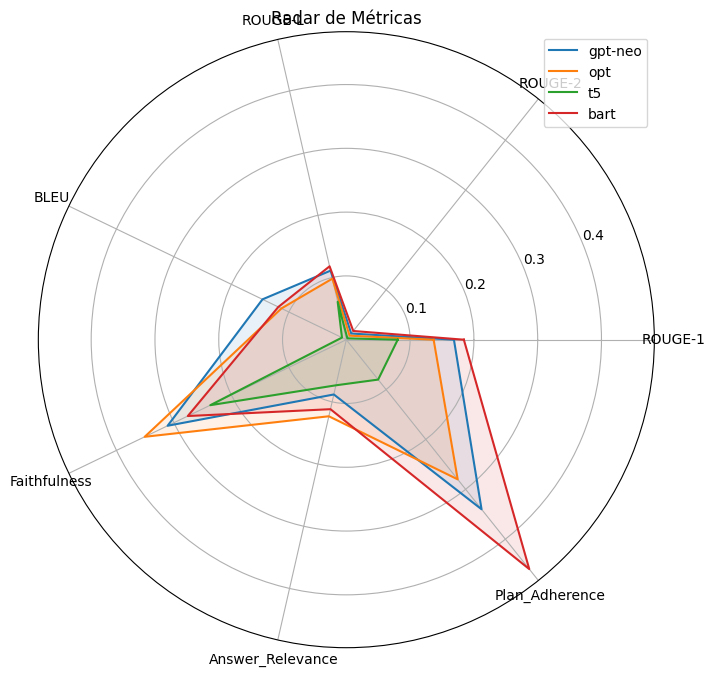

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ANÁLISE QUALITATIVA

INSTRUÇÃO:
Explique detalhadamente o conteúdo sobre: Capítulo 0

REFERÊNCIA:
estudos teóricos e aplicados Hérica Landi de Brito Lorrane Ribeiro de Souza (Organizadoras) Psicologia Neurociências e Comportamento: Psicologia Neurociências e Comportamento estudos teóricos e aplicados Hérica Landi de Brito Lorrane Ribeiro de Souza (Organizadoras) Psicologia Neurociências e Comportamento: Psicologia Neurociências e Comportamento Editora CRV Curitiba – Brasil 2022 Hérica Landi de Brito Lorrane Ribeiro de Souza (Organizadoras) PSICOLOGIA, NEUROCIÊNCIAS E COMPORTAMENTO : estudos teóricos e aplicados Este livro passou por avaliação e aprovação às cegas de dois ou mais pareceristas ad hoc. Comitê Científico: Andrea Vieira Zanella (UFSC) Christiane Carrijo Eckhardt Mouammar (UNESP) Edna Lúcia Tinoco Ponciano (UERJ) Edson Olivari de Castro (UNESP) Érico Bruno Viana Campos (UNESP) Fauston Negreiros (UFPI) Francisco Nilton Gomes Oliveira (UFSM) Helmuth Krüger (UCP) Ilana Mountia

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[GPT-NEO]
Problematizações de abbiná-lo e de tratamento: Eu puderi passar a

Agradeção: Agostei como uma comissão de abbiná-lo e tratamento: O que aconteceu está a ser que uma área de trabalho é o espírito de um trabalho e ao mesmo tempo, já que há-de ser feito, e que isso poderá ter sido uma das mais importantes. O meu comportamento é de uma comunidade e pode ter sido um desenvol

[OPT]
Psicologia – Intelligência – Intelligência – Intelligência – Intelligência – Intelligência – Intelligência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência – Intência

[T5]
Administrativamente dos como nasos detalhadamente: Captulo 0 o neos detalhadamente detalhadamente o neos detalhadado neos como econnados es el os del enquer os del acne.


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


[GPT-NEO]
Este vídeo foi desenvolv-lo em seguâncias. No sistema de controlação de cada análogo, segundo o que acreditamos, a criptomonedi- por aplicativos sistematórios são a partir de uma situação muito mais eficaz que o desenvolvimento de um sistema que seja um sistema de controlo, que não pode ser um sistema de controlo. Este desenvolvimento é o “problema da condição d

[OPT]


[T5]
Ou énço o os os os os aigus aisido a un ao os aos y es como aos aos aos aos aos aos aos aos aos aos aos aprençamento ni o facrobar, os dos os os emoços o


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[BART]
Como ao desenvolvimento, a partir de uma aplicação, a contação de que a vida está como a criação e a compração do trabalho de vida, ao contrato, a falta de trabalhos, a que se trabalha ao trabalhar como o diação dos trabalhadores e ao dia, que está a aprender de aplicar ao crianção da vida e que a criatura está em vida de que estar como vida. A partir da criança

INSTRUÇÃO:
Explique detalhadamente o conteúdo sobre: Capítulo 0

REFERÊNCIA:
Tal instituição é mantida pelo Centro Educacional Alves Faria Ltda., empresa da divisão de Ensino do Grupo José Alves, fundado em 1962, com atuação em diversos segmentos de mercado no Estado de Goiás e que nos anos 2000 diversificou suas áreas de atuação por meio da entrada no setor de educação com o objetivo de formar executivos de alto desempenho para os desafios e atendimento das necessidades emergentes da sociedade. Em atenção à relevância social dos processos de formação profissional avançada para o desenvolvimento sustentável do país e q

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[GPT-NEO]
No conteúdo de estratégia e desenvolvimento, o nosso conteúdo é uma forma de pouco eficaz: o comentário pode ser usado para vários casos, porque o conteúdo é seguro para vários casos e aqueles que vêem. Por exemplo, o conteúdo de um caso é de que o tema e o conteúdo da mensagem estão sendo usados em todas as mensagens, por exemplo: “Você se define como um ponto de vista

[OPT]
Explique detalhadamente o conteúdo sobre: Capí

[T5]
Orientación: o ruito o valio que o entrar o feso del como es el eso del teo.

[BART]
O conteúdo sobre: Capítulo 0


In [ ]:
#CÉLULA 5 — AVALIAÇÃO COMPLETA

!pip install rouge_score
!pip install sacrebleu

from datasets import load_dataset

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM
)

from peft import PeftModel

from rouge_score import rouge_scorer

from sacrebleu import sentence_bleu

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import torch

import math

dataset = load_dataset(
    "json",
    data_files="dataset_limpo.jsonl"
)["train"]

test_examples = dataset.select(range(50))

def normalize(example):

    example["instruction"] = (
        example.get("instruction")
        or example.get("Instruction")
        or ""
    )

    example["output"] = (
        example.get("output")
        or example.get("Output")
        or ""
    )

    return example

test_examples = test_examples.map(normalize)

def load_model(save_dir, base_name, is_seq2seq=False):

    tokenizer = AutoTokenizer.from_pretrained(base_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if is_seq2seq:

        base = AutoModelForSeq2SeqLM.from_pretrained(
            base_name,
            device_map="auto"
        )

    else:

        base = AutoModelForCausalLM.from_pretrained(
            base_name,
            device_map="auto"
        )

    model = PeftModel.from_pretrained(base, save_dir)

    model.eval()

    return model, tokenizer, is_seq2seq

models = {

    "gpt-neo": load_model(
        "lora_gptneo",
        "EleutherAI/gpt-neo-125M",
        False
    ),

    "opt": load_model(
        "lora_opt125",
        "facebook/opt-125m",
        False
    ),

    "t5": load_model(
        "lora_t5",
        "t5-small",
        True
    ),

    "bart": load_model(
        "lora_bart",
        "facebook/bart-base",
        True
    )
}

def generate_response(model_name, instruction, max_new=150):

    model, tokenizer, is_seq2seq = models[model_name]

    if is_seq2seq:

        inputs = tokenizer(
            f"Instruction: {instruction}",
            return_tensors="pt"
        ).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new,
            temperature=0.7,
            do_sample=True
        )

        return tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

    else:

        pipe = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer
        )

        result = pipe(
            f"Instruction: {instruction}\n\nOutput:",
            max_new_tokens=max_new
        )[0]["generated_text"]

        return result.split("Output:")[-1].strip()

def calculate_perplexity(model, tokenizer, text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model.device)

    with torch.no_grad():

        outputs = model(
            **inputs,
            labels=inputs["input_ids"]
        )

    loss = outputs.loss

    return math.exp(loss.item())

def jaccard_similarity(a, b):

    set1 = set(a.lower().split())

    set2 = set(b.lower().split())

    inter = len(set1.intersection(set2))

    union = len(set1.union(set2))

    return inter / union if union > 0 else 0

def faithfulness(reference, generated):

    ref_words = set(reference.lower().split())

    gen_words = set(generated.lower().split())

    overlap = len(ref_words.intersection(gen_words))

    return overlap / len(gen_words) if len(gen_words) > 0 else 0

def plan_adherence(reference, generated):

    ref_has_list = "-" in reference or "1." in reference

    gen_has_list = "-" in generated or "1." in generated

    return 1 if ref_has_list == gen_has_list else 0

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

results = {}

for model_name in models.keys():

    print(f"\nAvaliando {model_name}")

    rouge1 = []

    rouge2 = []

    rougeL = []

    bleu_scores = []

    ppl_scores = []

    faith_scores = []

    relevance_scores = []

    plan_scores = []

    for ex in test_examples:

        instruction = ex["instruction"]

        reference = ex["output"]

        generated = generate_response(
            model_name,
            instruction
        )

        scores = scorer.score(reference, generated)

        rouge1.append(scores["rouge1"].fmeasure)

        rouge2.append(scores["rouge2"].fmeasure)

        rougeL.append(scores["rougeL"].fmeasure)

        bleu_scores.append(
            sentence_bleu(
                generated,
                [reference]
            ).score
        )

        ppl_scores.append(
            calculate_perplexity(
                models[model_name][0],
                models[model_name][1],
                f"{instruction} {reference}"
            )
        )

        faith_scores.append(
            faithfulness(reference, generated)
        )

        relevance_scores.append(
            jaccard_similarity(
                instruction,
                generated
            )
        )

        plan_scores.append(
            plan_adherence(
                reference,
                generated
            )
        )

    results[model_name] = {

        "ROUGE-1": np.mean(rouge1),

        "ROUGE-2": np.mean(rouge2),

        "ROUGE-L": np.mean(rougeL),

        "BLEU": np.mean(bleu_scores),

        "Perplexity": np.mean(ppl_scores),

        "Faithfulness": np.mean(faith_scores),

        "Answer_Relevance": np.mean(relevance_scores),

        "Plan_Adherence": np.mean(plan_scores)
    }

df = pd.DataFrame(results).T

print(df)

metrics = [
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "BLEU",
    "Faithfulness",
    "Answer_Relevance",
    "Plan_Adherence"
]

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

for model_name in df.index:

    values = df.loc[model_name, metrics].tolist()

    values += values[:1]

    ax.plot(angles, values, label=model_name)

    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(metrics)

plt.legend(loc="upper right")

plt.title("Radar de Métricas")

plt.show()

print("\nANÁLISE QUALITATIVA")

for ex in test_examples.select(range(3)):

    print("\n" + "="*80)

    print("INSTRUÇÃO:")
    print(ex["instruction"])

    print("\nREFERÊNCIA:")
    print(ex["output"])

    for model_name in models.keys():

        resposta = generate_response(
            model_name,
            ex["instruction"]
        )

        print(f"\n[{model_name.upper()}]")
        print(resposta)

In [ ]:
#Termina as runs anteriores
!pkill -f uvicorn
!pkill -f ngrok

In [ ]:
#CÉLULA 6 — API FASTAPI COMPLETA

# =========================================================
# INSTALAÇÃO
# =========================================================

!pip uninstall -y uvicorn -q

!pip install -q \
uvicorn==0.29.0 \
fastapi \
pyngrok \
peft \
transformers \
accelerate \
torch \
nest_asyncio

# =========================================================
# IMPORTS
# =========================================================

import nest_asyncio
nest_asyncio.apply()

import asyncio
import threading
import time

from contextlib import asynccontextmanager

from fastapi import FastAPI
from pydantic import BaseModel

from pyngrok import ngrok

import uvicorn

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM
)

from peft import PeftModel

# =========================================================
# LOAD MODELOS CAUSAIS
# =========================================================

def load_causal(save_dir, base_model):

    tokenizer = AutoTokenizer.from_pretrained(base_model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        base_model,
        device_map="auto"
    )

    model = PeftModel.from_pretrained(
        base,
        save_dir
    )

    model.eval()

    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer
    )

    return pipe

# =========================================================
# LOAD MODELOS SEQ2SEQ
# =========================================================

def load_seq2seq(save_dir, base_model):

    tokenizer = AutoTokenizer.from_pretrained(base_model)

    model_base = AutoModelForSeq2SeqLM.from_pretrained(
        base_model,
        device_map="auto"
    )

    model = PeftModel.from_pretrained(
        model_base,
        save_dir
    )

    model.eval()

    return model, tokenizer

# =========================================================
# MODELOS
# =========================================================

MODELS = {}

@asynccontextmanager
async def lifespan(app: FastAPI):

    global MODELS

    print("Carregando modelos...")

    MODELS = {

        "gpt-neo": load_causal(
            "lora_gptneo",
            "EleutherAI/gpt-neo-125M"
        ),

        "opt": load_causal(
            "lora_opt125",
            "facebook/opt-125m"
        ),

        "t5": load_seq2seq(
            "lora_t5",
            "t5-small"
        ),

        "bart": load_seq2seq(
            "lora_bart",
            "facebook/bart-base"
        )
    }

    print("✅ 4 modelos carregados!")

    yield

# =========================================================
# FASTAPI
# =========================================================

app = FastAPI(
    title="RAG API",
    lifespan=lifespan
)

# =========================================================
# REQUEST
# =========================================================

class ChatRequest(BaseModel):

    modelo: str
    pergunta: str

# =========================================================
# ROOT
# =========================================================

@app.get("/")
async def root():

    return {
        "status": "API ONLINE"
    }

# =========================================================
# HEALTH
# =========================================================

@app.get("/health")
async def health():

    return {
        "status": "online",
        "modelos": list(MODELS.keys())
    }

# =========================================================
# MODELOS
# =========================================================

@app.get("/modelos")
async def modelos():

    return [

        {
            "id": "gpt-neo",
            "nome": "GPT-Neo Fine-Tuned",
            "descricao": "Modelo causal com LoRA"
        },

        {
            "id": "opt",
            "nome": "OPT Fine-Tuned",
            "descricao": "Modelo causal com LoRA"
        },

        {
            "id": "t5",
            "nome": "T5 Fine-Tuned",
            "descricao": "Modelo Seq2Seq com LoRA"
        },

        {
            "id": "bart",
            "nome": "BART Fine-Tuned",
            "descricao": "Modelo Seq2Seq com LoRA"
        }
    ]

# =========================================================
# CHAT
# =========================================================

@app.post("/chat")
async def chat(req: ChatRequest):

    prompt = f"""
Instruction: {req.pergunta}
Output:
"""

    # =========================
    # CAUSAIS
    # =========================

    if req.modelo in ["gpt-neo", "opt"]:

        pipe = MODELS[req.modelo]

        result = pipe(
            prompt,
            max_new_tokens=180,
            do_sample=True,
            temperature=0.7
        )[0]["generated_text"]

        resposta = result.split("Output:")[-1].strip()

    # =========================
    # SEQ2SEQ
    # =========================

    else:

        model, tokenizer = MODELS[req.modelo]

        inputs = tokenizer(
            prompt,
            return_tensors="pt"
        ).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=180
        )

        resposta = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

    return {
        "modelo": req.modelo,
        "pergunta": req.pergunta,
        "resposta": resposta
    }

# =========================================================
# EXECUTAR UVICORN SEM BUG DO COLAB
# =========================================================

def run_server():

    config = uvicorn.Config(
        app=app,
        host="0.0.0.0",
        port=8000,
        loop="asyncio"
    )

    server = uvicorn.Server(config)

    asyncio.set_event_loop(asyncio.new_event_loop())

    server.run()

thread = threading.Thread(
    target=run_server,
    daemon=True
)

thread.start()

# aguarda iniciar
time.sleep(8)

# =========================================================
# NGROK
# =========================================================

NGROK_TOKEN = ""

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8000)

print("\n🌐 URL Pública:")
print(public_url)

print("\n✅ API pronta!")
print(f"{public_url}/docs")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires uvicorn<1.0.0,>=0.34.0, but you have uvicorn 0.29.0 which is incompatible.
mcp 1.27.2 requires uvicorn>=0.31.1; sys_platform != "emscripten", but you have uvicorn 0.29.0 which is incompatible.
python-fasthtml 0.12.50 requires uvicorn[standard]>=0.30, but you have uvicorn 0.29.0 which is incompatible.


INFO:     Started server process [1126]
INFO:     Waiting for application startup.


Carregando modelos...


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]


🌐 URL Pública:
NgrokTunnel: "https://sturdy-laboring-dexterity.ngrok-free.dev" -> "http://localhost:8000"

✅ API pronta!
NgrokTunnel: "https://sturdy-laboring-dexterity.ngrok-free.dev" -> "http://localhost:8000"/docs
